In [2]:
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN import ESRNN
from ESRNN.utils_evaluation import Naive2, Naive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pickle


In [4]:
df = pd.read_csv(
    "/home/erti/PROJECT_repos/ForeST_HPO/hpo-innosuisse/data/2024-05-27 DE Auftragseingang Maschinenbau 28.00.csv"
)
df.columns

Index(['Datum', 'Insgesamt', 'Inland', 'Ausland', 'Ausland (Eurozone)',
       'Ausland (Nicht-Eurozone)'],
      dtype='object')

In [5]:
y_df = pd.DataFrame()
y_df["ds"] = pd.to_datetime(df["Datum"])
y_df["y"] = df["Insgesamt"]
y_df["unique_id"] = "Insgesamt"


In [6]:
assert y_df.isna().sum().sum() == 0, "There are NaN values in the data"

In [7]:
x_df = y_df.drop("y", 1)
x_df["x"] = "Macro"  # TODO

In [8]:
SPLIT_IDX = y_df[y_df.ds == pd.to_datetime("2017-01-31")].index[0]
print(SPLIT_IDX, SPLIT_IDX / len(y_df))

y_train_df = y_df.iloc[:SPLIT_IDX]
y_test_df = y_df.iloc[SPLIT_IDX:]

X_train_df = x_df.iloc[:SPLIT_IDX]
X_test_df = x_df.iloc[SPLIT_IDX:]

312 0.7819548872180451


In [9]:
# naive = Naive() # TODO use Naive2 or SesonalNaive
# naive.fit(y_test_df)

y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")

/tmp/nix-shell-81580-0/ipykernel_97013/1444109779.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")


In [ ]:
# ESRNN Default Inits
#     max_epochs=15,
#     batch_size=1,
#     batch_size_test=64,
#     freq_of_test=-1,
#     learning_rate=1e-3,
#     lr_scheduler_step_size=9,
#     lr_decay=0.9,
#     per_series_lr_multip=1.0,
#     gradient_eps=1e-8,
#     gradient_clipping_threshold=20,
#     rnn_weight_decay=0,
#     noise_std=0.001,
#     level_variability_penalty=80,
#     testing_percentile=50,
#     training_percentile=50,
#     ensemble=False,
#     cell_type="LSTM",
#     state_hsize=40,
#     dilations=[[1, 2], [4, 8]],
#     add_nl_layer=False,
#     seasonality=[4],
#     input_size=4,
#     output_size=8,
#     frequency=None,
#     max_periods=20,
#     random_seed=1,
#     device="cpu",
#     root_dir="./",


In [68]:
# Instantiate model

INPUT_SIZE = 12
OUTPUT_SIZE = 6

model = ESRNN(
    max_epochs=10,
    freq_of_test=5,
    learning_rate=5e-4,
    lr_scheduler_step_size=10,
    lr_decay=0.1,
    per_series_lr_multip=1.0, # 0.8
    # gradient_eps=
    gradient_clipping_threshold=50,
    rnn_weight_decay=0.0, # L2 Norm
    # noise_std=
    level_variability_penalty=50,
    testing_percentile=50,
    training_percentile=49, # Pinball Loss
    batch_size=1,  # assert self.batch_size <= self.n_series
    seasonality=[12],
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    # random_seed=
    # exogenous_size=
    # min_inp_seq_length=
    max_periods=25,
    cell_type="LSTM",
    state_hsize=50,
    dilations=[[1], [3], [6], [12]],
    add_nl_layer=False,
    random_seed=1,
    device="cuda",  # FIXED ERTI
    
    ensemble=False,
    
)

In [ ]:
# with open("forest_model.pkl", "rb") as f:
#     model = pickle.load(f)

In [69]:
# Fit model
# If y_test_df is provided the model will evaluate predictions on this set every freq_test epochs


model.fit(
    X_train_df,
    y_train_df,
    X_test_df,
    y_test_df,
)

with open("forest_model.pkl", "wb") as f:
    pickle.dump(model, f)


Infered frequency: M
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 0.45821
Training loss (49 prc): 0.24590
Testing loss  (50 prc): 0.04031
OWA: nan 
SMAPE: nan 
MASE: nan 
========= Epoch 1 finished =========
Training time: 0.32459
Training loss (49 prc): 0.24076
========= Epoch 2 finished =========
Training time: 0.34126
Training loss (49 prc): 0.23659
========= Epoch 3 finished =========
Training time: 0.32856
Training loss (49 prc): 0.23303
========= Epoch 4 finished =========
Training time: 0.32401
Training loss (49 prc): 0.22991
========= Epoch 5 finished =========
Training time: 0.32246
Training loss (49 prc): 0.22731
Testing loss  (50 prc): 0.02730
OWA: nan 
SMAPE: nan 
MASE: nan 
========= Epoch 6 finished =========
Training time: 0.32813
Training loss (49 prc): 0.22525
========= Epoch 7 finished =========
Training time: 0.32327
Training loss (49 prc): 0.22388
========= Epoch 8 finished =========
Training time: 0.32179
Trai

In [70]:
# Predict on test set
# HINT is only a "local" model. Can only predict contiguous to training and needs to be retrained
i = 0
y_hat_df = model.predict(X_test_df[i:i+OUTPUT_SIZE])

# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(
    y_hat_df,
    # y_train_df,
    y_df[:SPLIT_IDX+i],
    X_test_df[i:i+OUTPUT_SIZE],
    y_test_df[i:i+OUTPUT_SIZE],
    naive2_seasonality=1,
)

===============  Model evaluation  ==============
OWA: 0.521 
SMAPE: 4.278 
MASE: 0.8 


M4 Parameters:

    OWA: 0.966 
    SMAPE: 7.683 
    MASE: 1.528 

Monthly Parameters (Paper Table 1):

    OWA: 0.521 
    SMAPE: 4.278 
    MASE: 0.8 


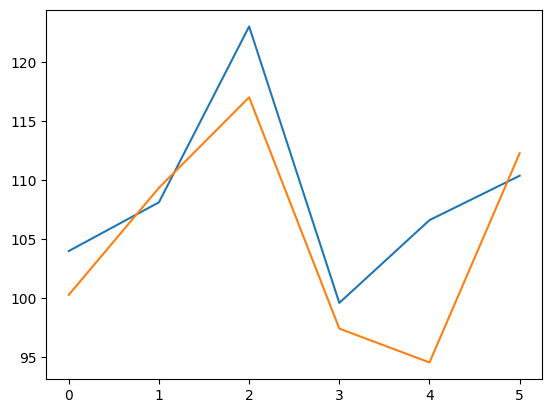

In [71]:
plt.plot(y_test_df[:6].y.values, label="y")
plt.plot(y_hat_df[:6].y_hat.values, label="y_hat")

In [72]:
y_hat_df["y_test"] = y_test_df["y"]

In [73]:
y_hat_df.to_csv("y_hat_df.csv")